In [1]:
import importlib
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
import pandas as pd
import numpy as np
from pathlib import Path
from shapely.geometry import LineString, Point, Polygon

from commute_analysis.synthetic_population import (
    calculate_sampling_probability_grid,
    sample_population_weighted_locations,
)
import commute_analysis.visualization as viz
import commute_analysis.routing as routing
import commute_analysis.geometry as geometry
import commute_analysis.scoring as scoring

BASE_DIR = "/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis"

# Force reload so notebook picks up local source changes during iterative development
importlib.reload(viz)
importlib.reload(scoring)

plot_commute_map = viz.plot_commute_map
plot_routes = viz.plot_routes
plot_sampling_probability_map = viz.plot_sampling_probability_map
plot_synthetic_employees = viz.plot_synthetic_employees

In [2]:
# ------------------------------------------------------------
# 1. Define target area
# ------------------------------------------------------------

RADIUS_KM = 50
WORKPLACE = (53.686439, 10.046120)

target_area = geometry.create_target_area(WORKPLACE[0], WORKPLACE[1], RADIUS_KM)

# ------------------------------------------------------------
# 2. Load population grid data
# ------------------------------------------------------------

population_df = pd.read_csv(Path(BASE_DIR) / "data" / "raw" / "population_grid.csv")

# transform this dataframe into a geopandas dataframe with a geometry column that contains the centroid of the grid cell
population_gdf = gpd.GeoDataFrame(
    population_df,
    geometry=gpd.points_from_xy(population_df["x_mp_100m"], population_df["y_mp_100m"]),
    crs="EPSG:3035",
)

# ------------------------------------------------------------
# 3. Calculate sampling probabilities
# ------------------------------------------------------------
GAUSSIAN_SCALE = 10_000

probability_grid = (
    calculate_sampling_probability_grid(
        population_grid=population_gdf,
        population_column="Einwohner",
        target_area=target_area,
        filter_mode="gaussian",
        gaussian_scale=GAUSSIAN_SCALE,
    )
    .copy()
)

In [12]:
NUM_EMPLOYEES = 100
synthetic_employees = sample_population_weighted_locations(population_gdf, "Einwohner", NUM_EMPLOYEES, target_area=target_area, filter_mode="gaussian", gaussian_scale=GAUSSIAN_SCALE)
employee_points = synthetic_employees.to_crs("EPSG:4326")

In [15]:
synthetic_employees

# save the synthetic dataset to the data/processed directory as a geopackage file
output_path = Path(BASE_DIR) / "data" / "processed" / "synthetic_employees.gpkg"
synthetic_employees.to_file(output_path, layer="synthetic_employees", driver="GPKG")

In [3]:
# load the synthetic dataset from the data/processed directory as a geopackage file and plot it
output_path = Path(BASE_DIR) / "data" / "processed" / "synthetic_employees.gpkg"
synthetic_employees = gpd.read_file(output_path, layer="synthetic_employees")
synthetic_employees

,employee_id,source_population,source_probability,distance_weight,geometry
0,EMP-00001,172.0,0.000113,0.620245,POINT (4331150 3390950)
1,EMP-00002,41.0,0.000026,0.603383,POINT (4319750 3406750)
2,EMP-00003,88.0,0.000081,0.868424,POINT (4328350 3394550)
3,EMP-00004,16.0,0.000009,0.542444,POINT (4329150 3387850)
4,EMP-00005,49.0,0.000034,0.652035,POINT (4320150 3406050)
...,...,...,...,...,...
95,EMP-00096,72.0,0.000066,0.865595,POINT (4325350 3392450)
96,EMP-00097,43.0,0.000007,0.144989,POINT (4335850 3381950)
97,EMP-00098,40.0,0.000012,0.282287,POINT (4311450 3387950)
98,EMP-00099,228.0,0.000099,0.410156,POINT (4318650 3385450)


<Axes: >

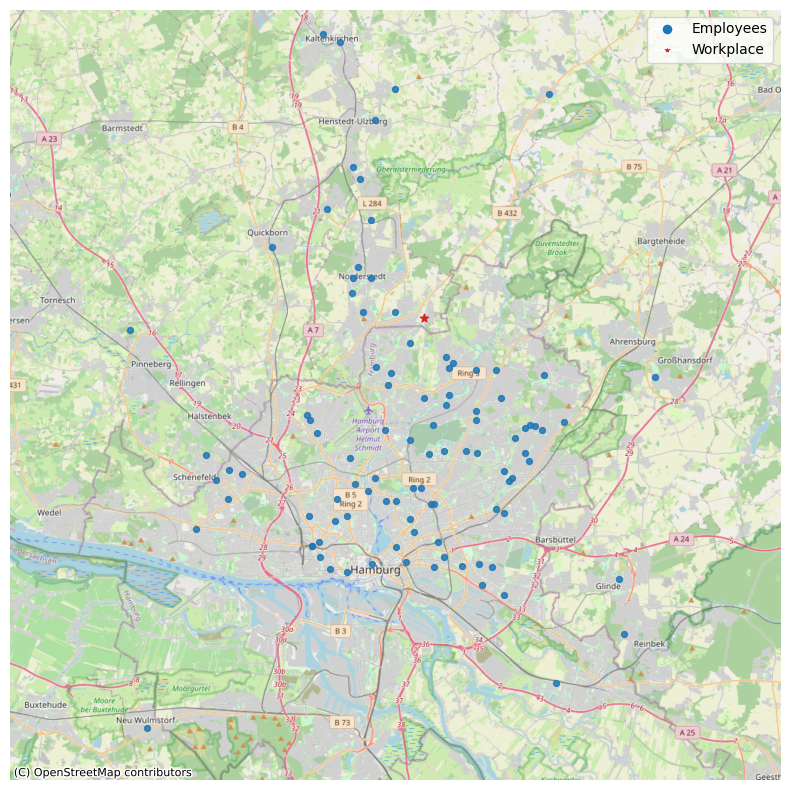

In [5]:
plot_synthetic_employees(
    synthetic_employees,
    target_area=None,
    workplace=WORKPLACE,
    backend="matplotlib",
    add_basemap=True,
    show_probability_grid=False,
)

In [17]:
DEPARTURE_TIME = "2026-09-15T07:00:00"

distance, time, route_1 = routing.route_between_points(synthetic_employees.iloc[0].geometry, WORKPLACE, transport_modes=["public_transit"], data_dir=Path(BASE_DIR) / "data" / "raw" / "osm", crs=synthetic_employees.crs, departure_time=DEPARTURE_TIME)
distance2, time2, route_2 = routing.route_between_points(synthetic_employees.iloc[0].geometry, WORKPLACE, transport_modes=["car"], data_dir=Path(BASE_DIR) / "data" / "raw" / "osm", crs=synthetic_employees.crs, departure_time=DEPARTURE_TIME)
print(time)

/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/transport_network.py:266: RuntimeWarning: R5 reported the following issues with GTFS file hvv_Rohdaten_GTFS_Fpl_26.ZIP: 
EmptyTableError: frequencies line 0: Table is present in zip file, but it has no entries.
  warnings.warn(


42.78333333333333


In [18]:
print(time2)

16.383333333333333


<Axes: title={'center': 'Fully combined static map'}>

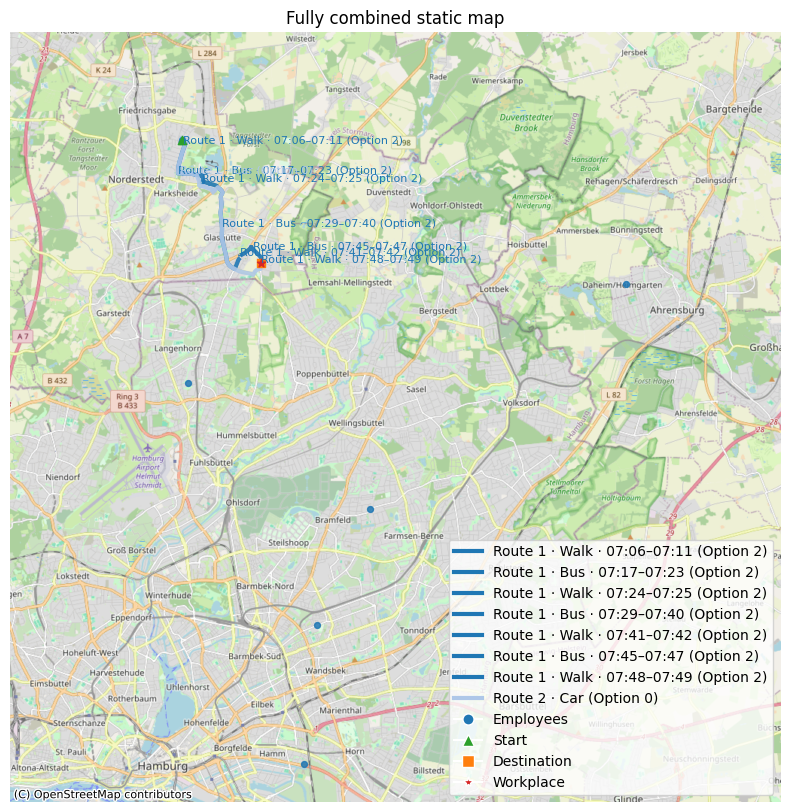

In [20]:
plot_commute_map(
    employees=synthetic_employees,
    workplace=WORKPLACE,
    routes=[route_1, route_2],
    route_origins=[employee_points.iloc[[0]]],
    route_destinations=WORKPLACE,
    backend="matplotlib",
    add_basemap=True,
    route_color_strategy="route",
    title="Fully combined static map",
)

In [21]:
synthetic_employees.head()
print(synthetic_employees.crs)

EPSG:3035


In [22]:
car_score = scoring.calculate_car_record(
    employee_id=synthetic_employees.iloc[0]["employee_id"], 
    direction="morning", 
    home=synthetic_employees.iloc[0]["geometry"], 
    home_crs=synthetic_employees.crs
    )
car_score.head()

,employee_id,direction,departure_time,travel_time,distance
0,EMP-00001,morning,07:00:00,16.383333,6.788678


In [23]:
public_transport_score = scoring.calculate_public_transport_record(
    employee_id=synthetic_employees.iloc[0]["employee_id"], 
    direction="morning", 
    home=synthetic_employees.iloc[0]["geometry"], 
    home_crs=synthetic_employees.crs
    )
public_transport_score.head()

,employee_id,direction,departure_time,travel_time,number_of_transfers,total_walking_time
0,EMP-00001,morning,07:00:00,42.783333,2,8.683333
1,EMP-00001,morning,07:10:00,32.983333,2,8.683333
2,EMP-00001,morning,07:20:00,39.883333,2,8.683333
3,EMP-00001,morning,07:30:00,39.600000,2,8.683333
4,EMP-00001,morning,07:40:00,40.183333,2,8.683333


In [24]:
public_transport_score

,employee_id,direction,departure_time,travel_time,number_of_transfers,total_walking_time
0,EMP-00001,morning,07:00:00,42.783333,2,8.683333
1,EMP-00001,morning,07:10:00,32.983333,2,8.683333
2,EMP-00001,morning,07:20:00,39.883333,2,8.683333
3,EMP-00001,morning,07:30:00,39.600000,2,8.683333
4,EMP-00001,morning,07:40:00,40.183333,2,8.683333
5,EMP-00001,morning,07:50:00,36.633333,2,8.683333
6,EMP-00001,morning,08:00:00,40.183333,2,7.516667
7,EMP-00001,morning,08:10:00,37.066667,2,7.516667
8,EMP-00001,morning,08:20:00,46.950000,1,25.033333
9,EMP-00001,morning,08:30:00,56.166667,0,42.700000


In [11]:
transport_score = scoring.calculate_employee_transport_score(
    employee_id=synthetic_employees.iloc[1]["employee_id"],
    home=synthetic_employees.iloc[1]["geometry"],
    home_crs=synthetic_employees.crs
)

In [12]:
print(transport_score)

EmployeeTransportScoreResult(employee_id='EMP-00002', transport_score=0.5748846841772401, relative_time_score=0.1837424404126645, absolute_time_score=0.4015740740740741, consistency_score=1.0, walking_score=0.6605555555555556, transfers_score=0.625, pt_travel_time_p25_total=107.71666666666667, car_route_record=  employee_id direction departure_time  travel_time   distance
0   EMP-00002   morning       07:00:00    35.033333  18.556249
1   EMP-00002   evening       16:00:00    27.433333  16.300544, pt_route_record=   employee_id direction departure_time  travel_time  number_of_transfers  \
0    EMP-00002   morning       07:00:00    62.616667                    2   
1    EMP-00002   morning       07:10:00    56.166667                    3   
2    EMP-00002   morning       07:20:00    53.100000                    2   
3    EMP-00002   morning       07:30:00    49.883333                    3   
4    EMP-00002   morning       07:40:00    53.400000                    2   
5    EMP-00002   mor

In [8]:
score_df, route_df = scoring.calculate_transport_scores_for_geodataframe(
    employee_gdf=synthetic_employees,
    employee_id_column="employee_id",
    home_column="geometry",
    home_crs=synthetic_employees.crs,
    max_workers=6,
    save_df=True,
    overwrite=False,
    save_dir=Path(BASE_DIR) / "data" / "processed",
)

/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/transport_network.py:266: RuntimeWarning: R5 reported the following issues with GTFS file hvv_Rohdaten_GTFS_Fpl_26.ZIP: 
EmptyTableError: frequencies line 0: Table is present in zip file, but it has no entries.
  warnings.warn(


Processed 1/10 employees
Processed 2/10 employees
Processed 3/10 employees
Processed 4/10 employees
Processed 5/10 employees
Processed 6/10 employees
Processed 7/10 employees
Processed 8/10 employees
Processed 9/10 employees
Processed 10/10 employees


In [4]:
synthetic_employees

,employee_id,source_population,source_probability,distance_weight,geometry
0,EMP-00001,172.0,0.000113,0.620245,POINT (4331150 3390950)
1,EMP-00002,41.0,0.000026,0.603383,POINT (4319750 3406750)
2,EMP-00003,88.0,0.000081,0.868424,POINT (4328350 3394550)
3,EMP-00004,16.0,0.000009,0.542444,POINT (4329150 3387850)
4,EMP-00005,49.0,0.000034,0.652035,POINT (4320150 3406050)
...,...,...,...,...,...
95,EMP-00096,72.0,0.000066,0.865595,POINT (4325350 3392450)
96,EMP-00097,43.0,0.000007,0.144989,POINT (4335850 3381950)
97,EMP-00098,40.0,0.000012,0.282287,POINT (4311450 3387950)
98,EMP-00099,228.0,0.000099,0.410156,POINT (4318650 3385450)


In [3]:
score_df, route_df = scoring.load_transport_scores_from_gpkg(save_dir=Path(BASE_DIR) / "data" / "processed")

In [4]:
score_df

,employee_id,total_travel_time,transport_score,relative_time_score,absolute_time_score,consistency_score,walking_score,transfers_score,geometry
0,EMP-00003,66.966667,0.536826,0.324230,0.627963,0.488054,0.773611,0.750,POINT (4328350 3394550)
1,EMP-00005,141.500000,0.369202,0.349907,0.213889,0.551583,0.127778,0.500,POINT (4320150 3406050)
2,EMP-00002,130.433333,0.415056,0.385941,0.275370,0.536039,0.389167,0.500,POINT (4319750 3406750)
3,EMP-00001,114.566667,0.542417,0.545822,0.363519,0.641107,0.477500,0.750,POINT (4331150 3390950)
4,EMP-00004,131.916667,0.510168,0.514158,0.267130,0.695874,0.560833,0.500,POINT (4329150 3387850)
...,...,...,...,...,...,...,...,...,...
95,EMP-00092,113.183333,0.657680,0.836665,0.371204,0.704322,0.694167,0.750,POINT (4320850 3382850)
96,EMP-00100,80.450000,0.519666,0.243140,0.553056,0.639929,0.536389,0.750,POINT (4324050 3392850)
97,EMP-00099,137.416667,0.492351,0.453115,0.236574,0.759393,0.421111,0.500,POINT (4318650 3385450)
98,EMP-00098,181.200000,0.459380,0.615160,0.000000,0.764283,0.638056,0.125,POINT (4311450 3387950)


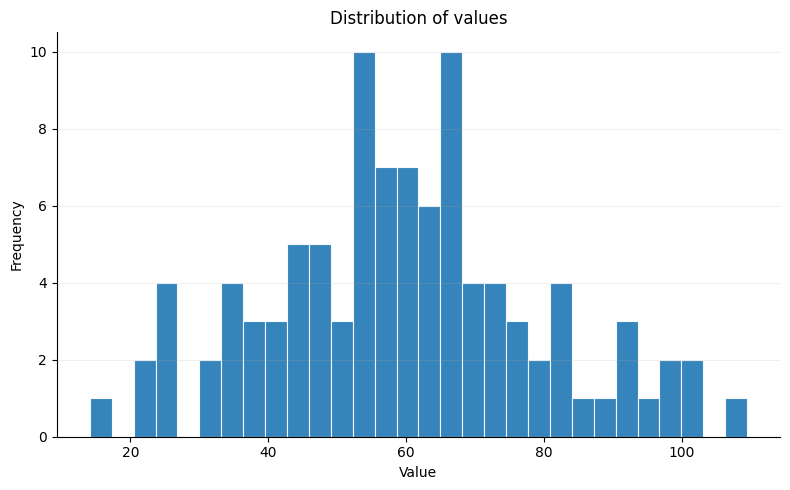

In [5]:
data = score_df.total_travel_time/2

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    data,
    bins=30,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
)

ax.set(
    title="Distribution of values",
    xlabel="Value",
    ylabel="Frequency",
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

In [6]:
viz.plot_histogram(data)

AttributeError: module 'commute_analysis.visualization' has no attribute 'plot_histogram'

In [6]:
route_df

,employee_id,home,geometry
0,EMP-00003,POINT (4328350 3394550),"MULTILINESTRING ((10.04582 53.68608, 10.04584 ..."
1,EMP-00005,POINT (4320150 3406050),"MULTILINESTRING ((9.98702 53.7618, 9.98752 53...."
2,EMP-00002,POINT (4319750 3406750),"MULTILINESTRING ((9.98138 53.77084, 9.9815 53...."
3,EMP-00001,POINT (4331150 3390950),"MULTILINESTRING ((10.04582 53.68608, 10.04584 ..."
4,EMP-00004,POINT (4329150 3387850),"MULTILINESTRING ((10.04582 53.68608, 10.04584 ..."
...,...,...,...
95,EMP-00092,POINT (4320850 3382850),"MULTILINESTRING ((9.99813 53.55388, 9.99712 53..."
96,EMP-00100,POINT (4324050 3392850),"MULTILINESTRING ((10.04582 53.68608, 10.04584 ..."
97,EMP-00099,POINT (4318650 3385450),"MULTILINESTRING ((9.96243 53.5782, 9.96244 53...."
98,EMP-00098,POINT (4311450 3387950),"MULTILINESTRING ((9.85676 53.59912, 9.85663 53..."


<Axes: >

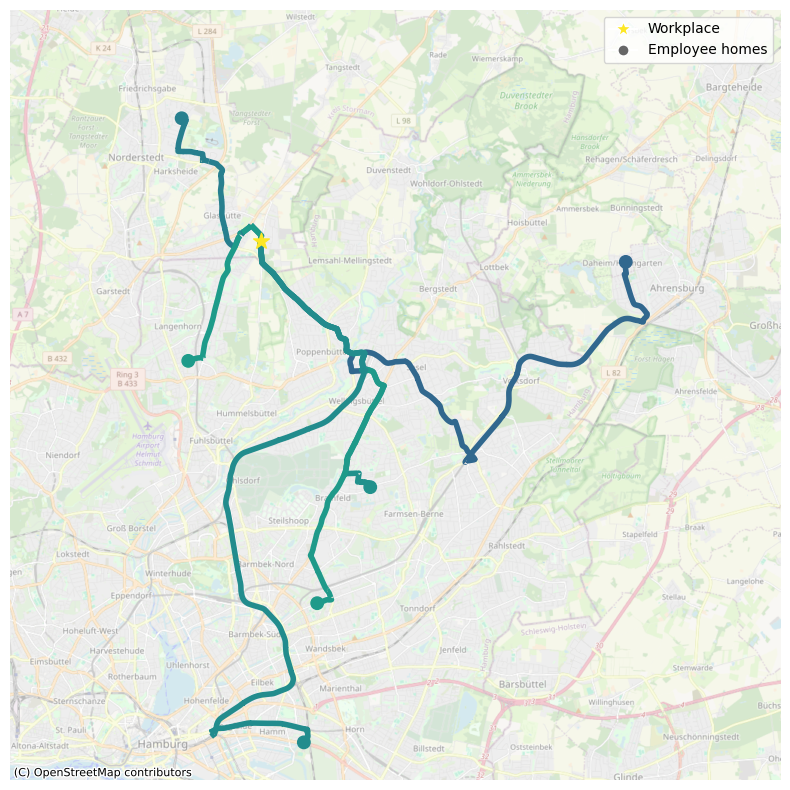

In [46]:
viz.plot_transport_score_routes(
    summary_gdf=score_df,
    route_gdf=route_df,
    workplace=WORKPLACE,
    add_basemap=True,
    fit_bounds=True,
    fit_bounds_padding_fraction=0.02,
    home_markersize=80,
    workplace_markersize=140,
    route_linewidth=4,
    route_alpha=1,
    home_alpha=1,
    score_cmap="viridis",
    show_colorbar=False,
    colorbar_label="Transport score",
)

In [13]:
for column in ["travel_time", "number_of_transfers", "total_walking_time"]:
    print(f"{column} 25th percentile: {public_transport_score[column].quantile(.25)}")
    print(f"{column} 75th percentile: {public_transport_score[column].quantile(.75)}")

travel_time 25th percentile: 53.266666666666666
travel_time 75th percentile: 60.68333333333333
number_of_transfers 25th percentile: 1.0
number_of_transfers 75th percentile: 2.0
total_walking_time 25th percentile: 17.25
total_walking_time 75th percentile: 17.55


In [ ]:
synthetic_employees = gpd.read_file(Path(BASE_DIR) / "data" / "processed" / "synthetic_employees_test.gpkg", layer="synthetic_employees")


In [16]:
DATA_DIR = data_dir=Path(BASE_DIR) / "data" / "raw" / "osm"
transport_network = routing.build_transport_network(DATA_DIR)

/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/base_travel_time_matrix.py:227: RuntimeWarning: Some destination points could not be snapped to the street network
  warnings.warn(
/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/base_travel_time_matrix.py:227: RuntimeWarning: Some destination points could not be snapped to the street network
  warnings.warn(
/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/base_travel_time_matrix.py:227: RuntimeWarning: Some destination points could not be snapped to the street network
  warnings.warn(
/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/base_travel_time_matrix.py:227: RuntimeWarning: Some destination points could not be snapped to the street network
  warnings.warn(
/home/msing/proj/jjdatascience/deuts

0    0.0
1    0.0
Name: adoption_score, dtype: float64


/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/base_travel_time_matrix.py:227: RuntimeWarning: Some origin points could not be snapped to the street network
  warnings.warn(
/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/base_travel_time_matrix.py:227: RuntimeWarning: Some origin points could not be snapped to the street network
  warnings.warn(
/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/base_travel_time_matrix.py:227: RuntimeWarning: Some origin points could not be snapped to the street network
  warnings.warn(
/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/r5py/r5/base_travel_time_matrix.py:227: RuntimeWarning: Some origin points could not be snapped to the street network
  warnings.warn(
